# Zomato Data  Analysis Using Python


step1:- import required libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

step2:Craete Dataframa

In [3]:
df= pd.read_csv('C:/Users/acer/Desktop/Zomato/Data/Zomato data .csv')
print(df.head())


                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


Convert the Data type of column -rate 

In [4]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)

df['rate']=df['rate'].apply(handleRate)
print(df.head())



                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


understand the dataset

no of rows and columns

In [5]:
print("Dataset Shape:",df.shape)

Dataset Shape: (148, 7)


display all column names 

In [6]:
print(df.columns.tolist())

['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']


check data types and non-null values

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB


In [8]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


1.What type of restaurant do the majority of customers order from?

In [10]:
restaurant_type_counts=df['listed_in(type)'].value_counts()
print(restaurant_type_counts)

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


Visualization

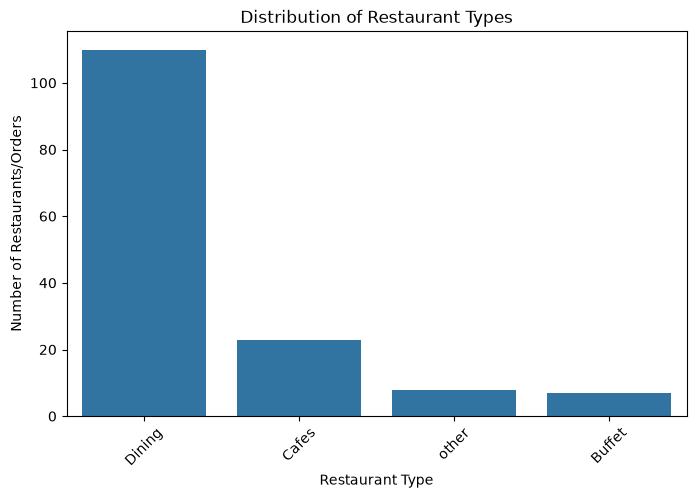

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='listed_in(type)',
    order=df['listed_in(type)'].value_counts().index

)
plt.title('Distribution of Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants/Orders')
plt.xticks(rotation=45)
plt.show()

In [13]:
# Identify the most common restaurant type
most_common_type=restaurant_type_counts.idxmax()
most_common_count=restaurant_type_counts.max()
print(
    f"The majority of customers/orders are associated with"
f"the '{most_common_type}' restaurant type,with {most_common_count} records."
)


The majority of customers/orders are associated withthe 'Dining' restaurant type,with 110 records.


Business insight:
This helps Zomato identify the restaurant category with the highest representation in the dataset, which can be useful for targeted promotions and partnerships.

Question 2
How many votes has each type of restaurant received from customers?

In [14]:
votes_by_type=df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False)
print(votes_by_type)


listed_in(type)
Dining    20363
other      9367
Cafes      6434
Buffet     3028
Name: votes, dtype: int64


Visualization

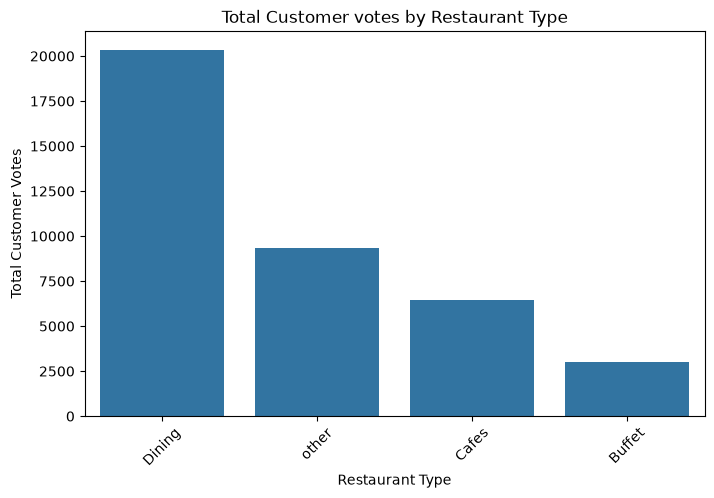

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=votes_by_type.index,
    y=votes_by_type.values
)
plt.title('Total Customer votes by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Total Customer Votes')
plt.xticks(rotation=45)
plt.show()

In [16]:
highest_voted_type=votes_by_type.idxmax()
highest_votes=votes_by_type.max()
print(
    f" '{highest_voted_type}' has received the highest number of customer votes"
    f" with a total of {highest_votes} votes."
)

 'Dining' has received the highest number of customer votes with a total of 20363 votes.


Business insight:
Customer votes indicate engagement. Restaurant categories receiving more votes may have higher customer interaction and visibility on the platform.

Question 3
What are the ratings that the majority of restaurants have received?

In [17]:
print(df['rate'].unique())

[4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 2.9 3.5 2.6
 3.4]


In [19]:
rating_count=df['rate'].value_counts().sort_index()
print(rating_count)

rate
2.6     1
2.8     2
2.9     7
3.0     2
3.1     7
3.2     7
3.3    14
3.4    12
3.5     6
3.6    11
3.7    15
3.8    20
3.9    10
4.0    10
4.1    11
4.2     8
4.3     1
4.4     2
4.6     2
Name: count, dtype: int64


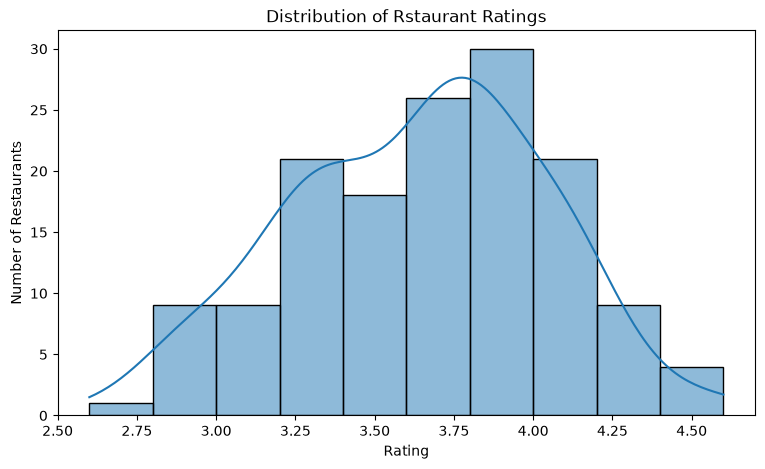

In [20]:
plt.figure(figsize=(9,5))
sns.histplot(
    df['rate'].dropna(),
    bins=10,
    kde=True
)
plt.title('Distribution of Rstaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()

In [21]:
#find the rating received by the highest number of restaurants
most_common_rating=df['rate'].mode()[0]
print(
    f"The most common restaurants rating in the dataset  is {most_common_rating}/5"
    
)

The most common restaurants rating in the dataset  is 3.8/5


Business Question 4
What is the average spending of couples on each online order?

In [22]:
# Check the unique values of the cost column
print(df['approx_cost(for two people)'].unique())

[800 300 600 700 550 500 450 650 400 900 200 750 150 850 100 350 250 950]


In [23]:
# Convert the cost column from object/string to numeric
# First remove commas if they exist

df['cost_for_two'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['cost_for_two'] = pd.to_numeric(
    df['cost_for_two'],
    errors='coerce'
)

In [24]:
# Filter restaurants/orders where online ordering is available

online_orders = df[df['online_order'].str.strip().str.lower() == 'yes']

# Calculate the average approximate cost for two people
average_online_spending = online_orders['cost_for_two'].mean()

print(
    f"Average spending for an online order for two people is "
    f"₹{average_online_spending:.2f}"
)

Average spending for an online order for two people is ₹510.34


Business insight:
The average spending estimate helps Zomato understand the typical order value for online customers and can support decisions related to discounts, coupons and promotional offers.

In [26]:
# Calculate the average rating for online and offline orders

rating_by_order_mode = (
    df.groupby('online_order')['rate']
      .mean()
      .sort_values(ascending=False)
)

print(rating_by_order_mode)

online_order
Yes    3.858621
No     3.487778
Name: rate, dtype: float64


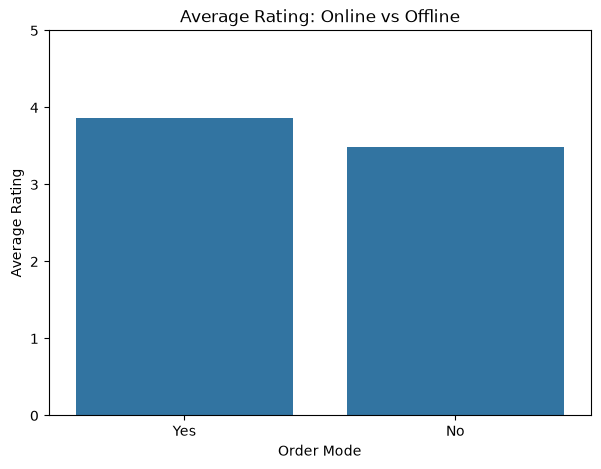

In [27]:
# Compare average ratings between online and offline ordering

plt.figure(figsize=(7, 5))

sns.barplot(
    x=rating_by_order_mode.index,
    y=rating_by_order_mode.values
)

plt.title('Average Rating: Online vs Offline')
plt.xlabel('Order Mode')
plt.ylabel('Average Rating')
plt.ylim(0, 5)

plt.show()

In [ ]:
# Identify the ordering mode with the highest average rating

highest_rated_mode = rating_by_order_mode.idxmax()
highest_mode_rating = rating_by_order_mode.max()

print(
    f"The '{highest_rated_mode}' ordering mode has the highest average rating "
    f"of {highest_mode_rating:.2f}/5."
)

In [28]:
# Identify the ordering mode with the highest average rating

highest_rated_mode = rating_by_order_mode.idxmax()
highest_mode_rating = rating_by_order_mode.max()

print(
    f"The '{highest_rated_mode}' ordering mode has the highest average rating "
    f"of {highest_mode_rating:.2f}/5."
)

The 'Yes' ordering mode has the highest average rating of 3.86/5.


Business insight:
Comparing online and offline ratings helps Zomato understand whether customers have different satisfaction levels depending on the ordering mode.

Business Question 6
Which type of restaurant received more offline orders?

In [29]:
# Filter the dataset to include only offline orders

offline_orders = df[
    df['online_order'].str.strip().str.lower() == 'no'
]

# Count offline orders/records for each restaurant type

offline_by_type = (
    offline_orders['listed_in(type)']
    .value_counts()
    .sort_values(ascending=False)
)

print(offline_by_type)

listed_in(type)
Dining    77
Cafes      8
Buffet     3
other      2
Name: count, dtype: int64


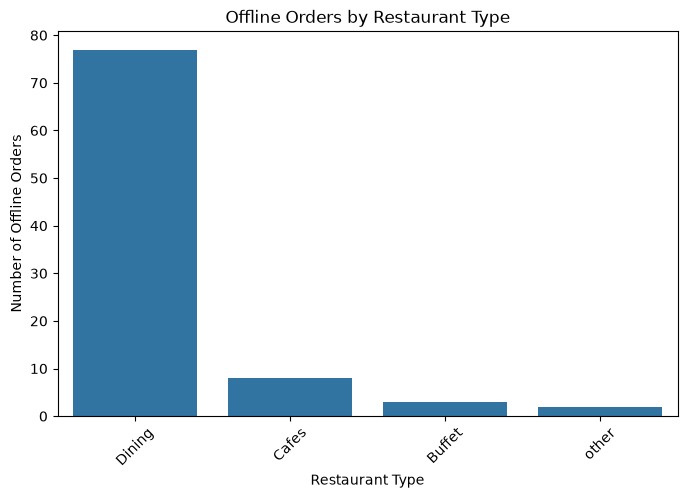

In [31]:
 # Visualize offline orders by restaurant type

plt.figure(figsize=(8, 5))

sns.barplot(
    x=offline_by_type.index,
    y=offline_by_type.values
)

plt.title('Offline Orders by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Offline Orders')
plt.xticks(rotation=45)

plt.show()

In [32]:
# Identify the restaurant type with the highest number of offline orders

highest_offline_type = offline_by_type.idxmax()
highest_offline_count = offline_by_type.max()

print(
    f"'{highest_offline_type}' has the highest number of offline orders "
    f"with {highest_offline_count} records."
)

'Dining' has the highest number of offline orders with 77 records.


## 📌 Key Takeaways

The analysis provides insights into customer preferences, restaurant engagement,
ratings, spending behavior, and ordering modes.

### Key findings:
- Identified the most popular restaurant type.
- Compared customer votes across restaurant categories.
- Identified the most common restaurant rating.
- Calculated the average spending for online orders for two people.
- Compared customer ratings between online and offline ordering.
- Identified restaurant categories with the highest offline ordering activity.

These insights can help Zomato design targeted promotional campaigns,
improve customer engagement, and encourage offline customers to adopt
online food ordering.